In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.precision', 3)

In [2]:
# Extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox, norm
from statsmodels.genmod.generalized_linear_model import GLM

In [3]:
import warnings
warnings.filterwarnings('ignore')

# 1. Analyzing the dataset

[YAPPING]

In [4]:
raw_data = read_csv("train_features_ILDS.csv", delimiter = ',', header = None)
raw_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
raw_data['Target'] = read_csv("train_labels_ILDS.csv", delimiter=',', header = None)
raw_data['Female'] = raw_data['Female'].astype('category')
raw_data['Target'] = raw_data['Target'].astype('category')

raw_data.shape #tamany

(463, 11)

In [5]:
raw_data.head()

,Age,Female,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,Target
0,40,0,3.9,1.7,350,950,1500,6.7,3.8,1.30,0
1,48,0,4.5,2.3,282,13,74,7.0,2.4,0.52,0
2,39,0,1.9,0.9,180,42,62,7.4,4.3,1.38,0
3,23,0,1.0,0.3,212,41,80,6.2,3.1,1.00,0
4,42,1,0.7,0.2,152,35,81,6.2,3.2,1.06,0


In [6]:
raw_data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR
count,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000
mean,44.881,3.279,1.446,279.866,75.844,97.607,6.422,3.110,0.943
std,16.309,6.115,2.675,211.283,169.290,212.114,1.052,0.793,0.318
min,4.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,176.000,23.000,25.000,5.700,2.500,0.700
50%,45.000,1.000,0.300,208.000,34.000,41.000,6.500,3.100,0.920
75%,57.500,2.700,1.300,291.000,60.000,83.500,7.100,3.700,1.100
max,90.000,75.000,18.300,1630.000,2000.000,2946.000,9.500,5.500,2.800


In [7]:
print(raw_data[raw_data['Female'] == 1]['Target'].value_counts())
print(raw_data[raw_data['Female'] == 0]['Target'].value_counts())

Target
0    74
1    38
Name: count, dtype: int64
Target
0    257
1     94
Name: count, dtype: int64


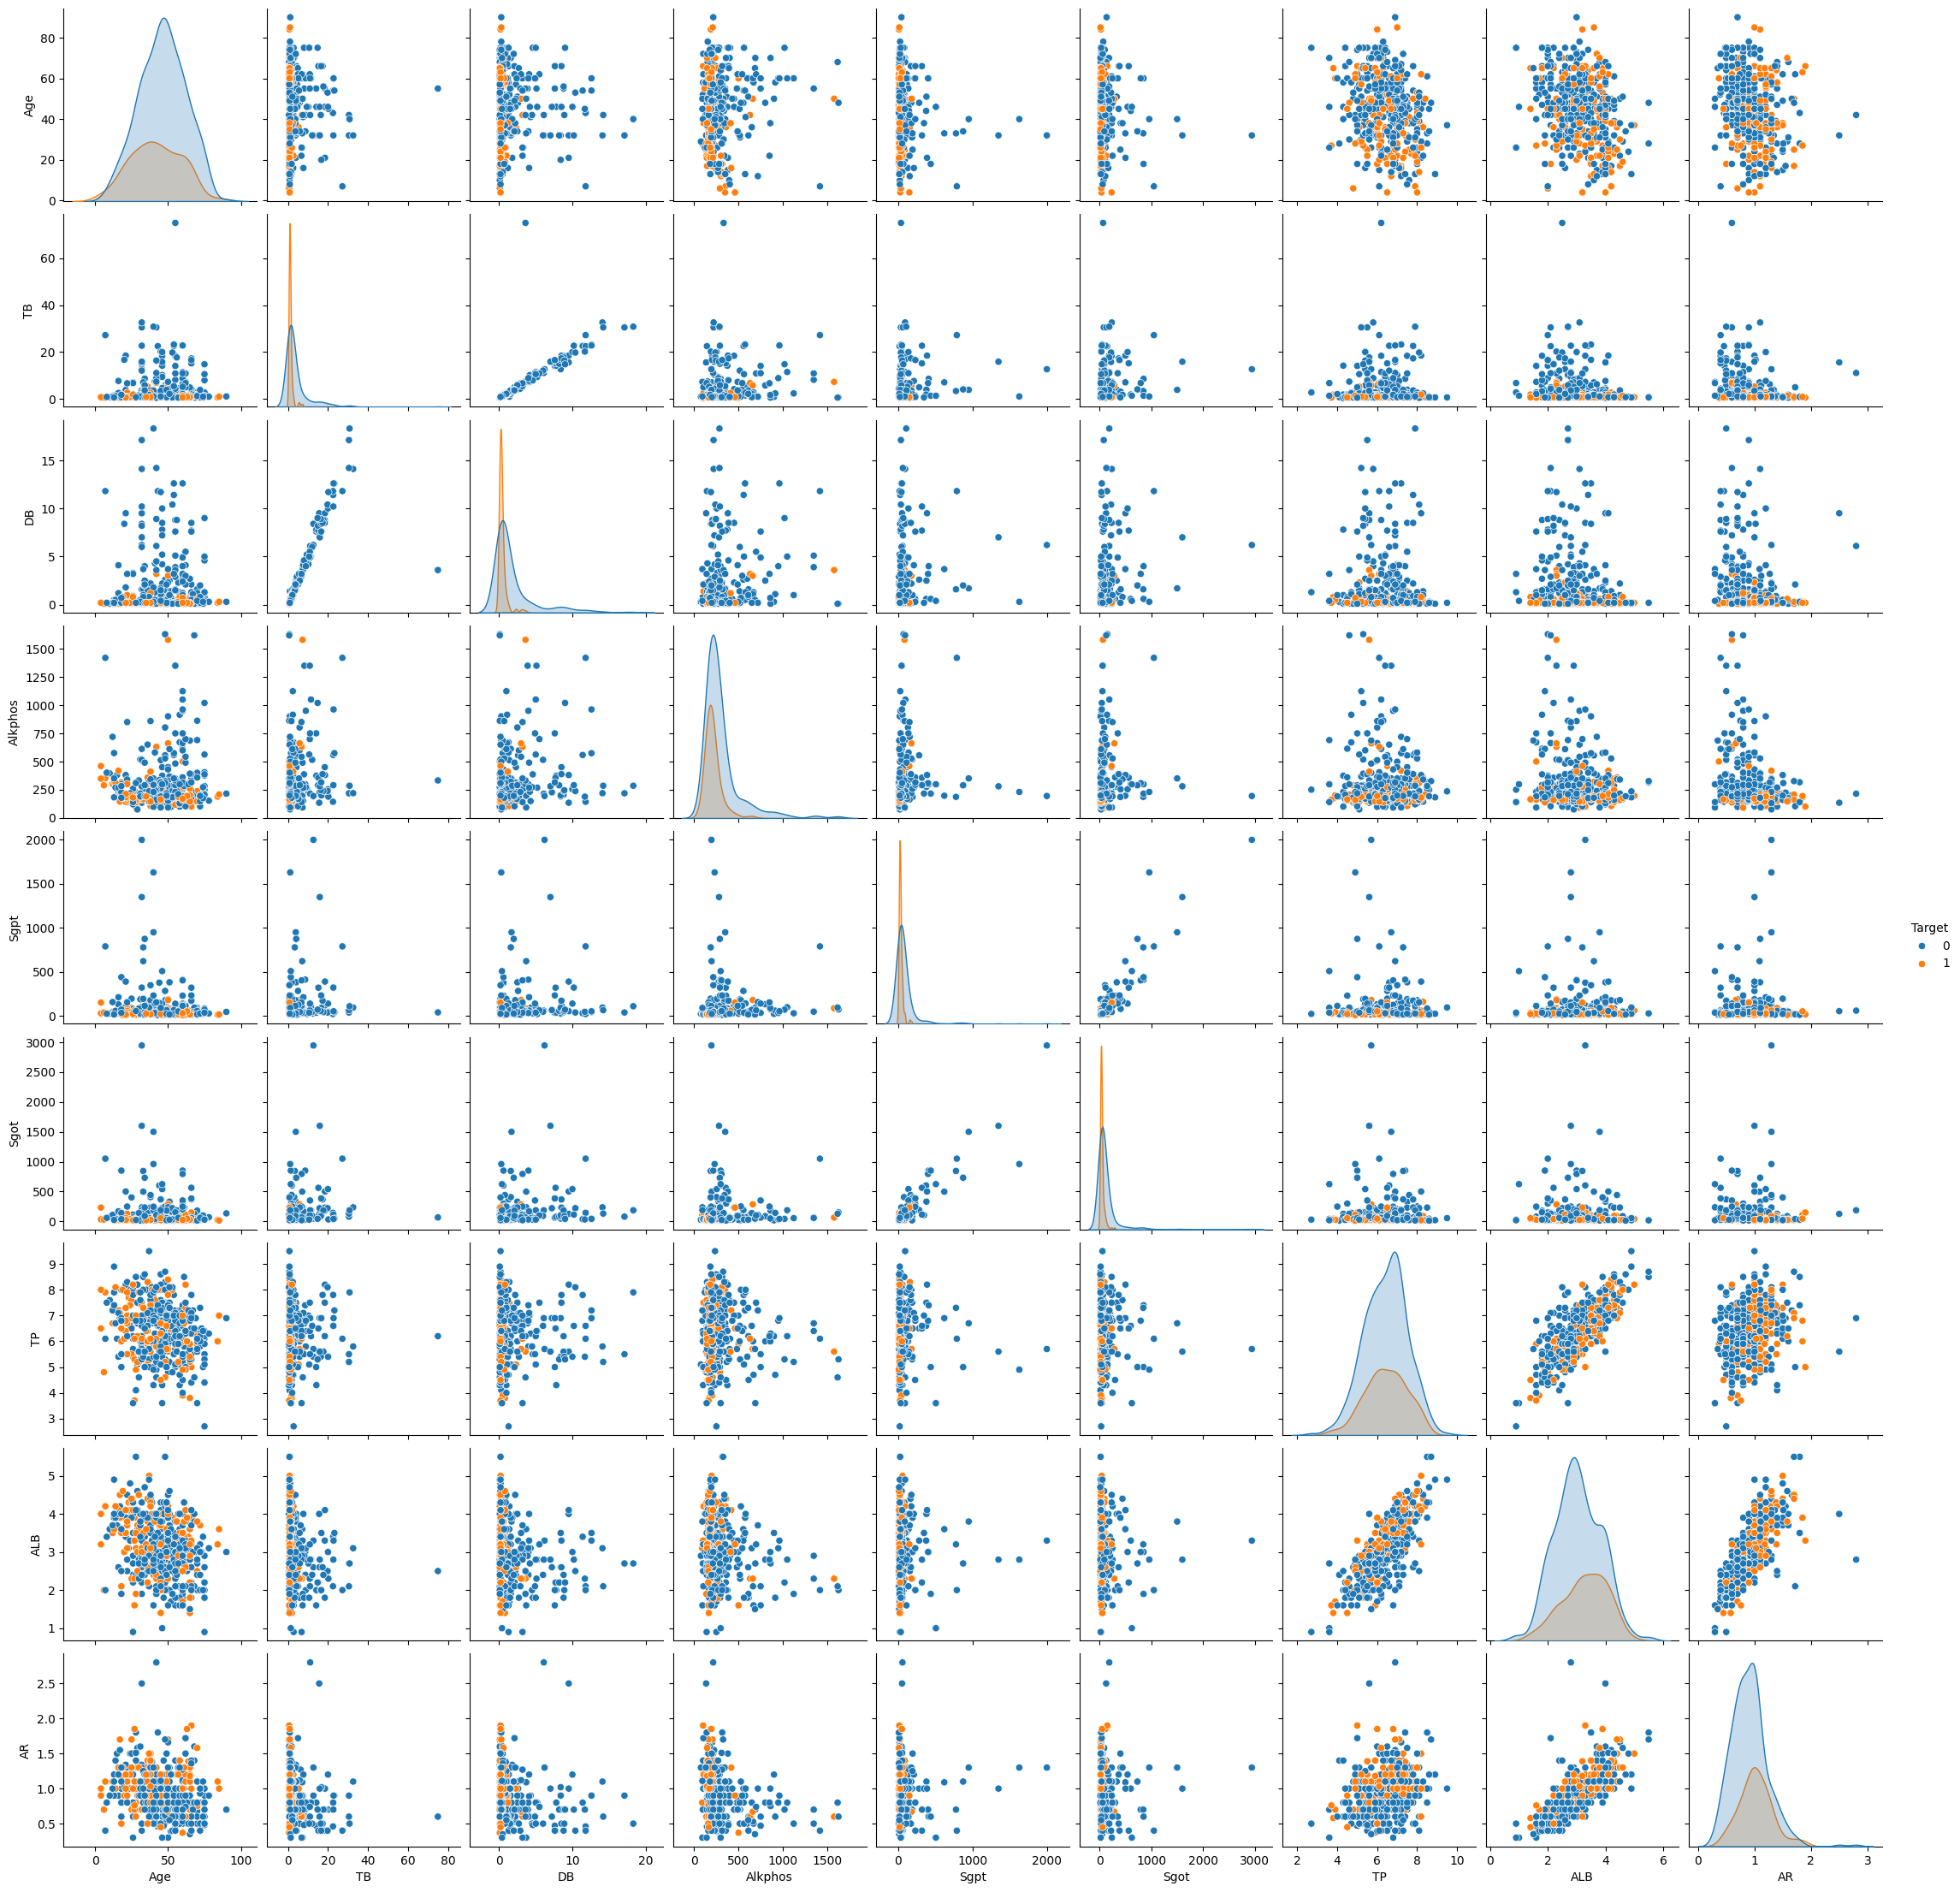

In [8]:
sns.pairplot(raw_data, hue = "Target")

In [9]:
raw_numdata = raw_data.drop(columns = ["Female", "Target"])
corr = raw_numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = raw_numdata @ U

print(eigs)
print(X_pca.shape)

[2.82463156 2.10174352 1.43118055 0.84093437 0.88460761 0.63952997
 0.044745   0.0830351  0.14959234]
(463, 9)


<Figure size 600x400 with 0 Axes>

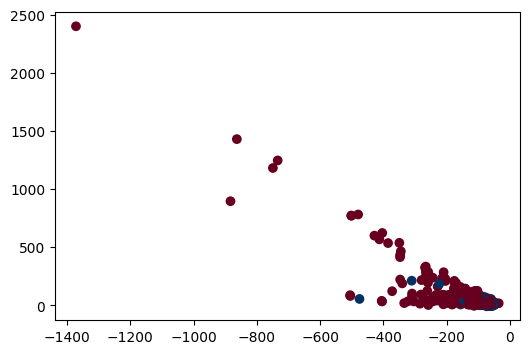

In [10]:
x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = raw_data['Target'], cmap = "RdBu")

In [11]:
sick_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 0]
corr = sick_numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = sick_numdata @ U

print(eigs)
print(X_pca.shape)

[2.72097017 2.14208179 1.47309362 0.90460943 0.79655931 0.66467459
 0.15957238 0.05497367 0.08346502]
(331, 9)


<Figure size 600x400 with 0 Axes>

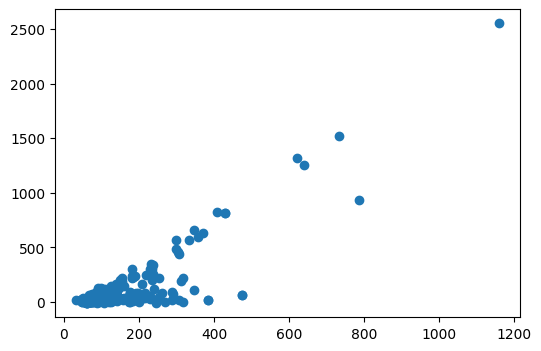

In [12]:
x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, cmap = "RdBu")

In [13]:
healthy_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 1]
corr = healthy_numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = healthy_numdata @ U

print(eigs)
print(X_pca.shape)

[3.31745296 2.18729537 1.13108032 1.00219726 0.65735369 0.41528247
 0.26302742 0.01553821 0.0107723 ]
(132, 9)


<Figure size 600x400 with 0 Axes>

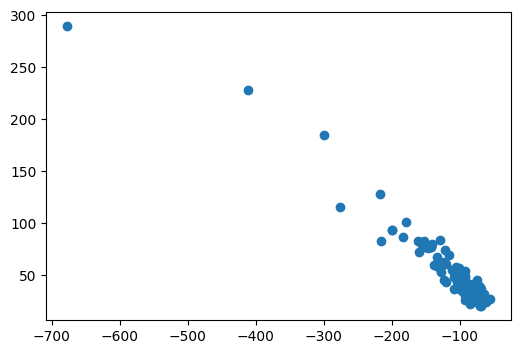

In [14]:
x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, cmap = "RdBu")

# 2. Identifying anomalies

First of all, we have found clear anormal individuals (healthy and sick) which we should eliminate. Not eliminating them can be problematic when fitting the models or if we want to do resampling.